In [1]:
#Load packages
import warnings
warnings.filterwarnings("ignore")
from watermark import watermark

#file operating
import os
import os.path
import re
import sys
from functools import reduce

#data processing platform
import anndata as ad
import geopandas as gpd
import numpy as np
import pandas as pd
import spatialdata as sd
import spatialdata_plot
import scanpy as sc
from affine import Affine
from collections import Counter
from shapely import affinity
from rasterio.features import rasterize
from scipy.ndimage import binary_dilation
from shapely.geometry import Polygon
from spatialdata import bounding_box_query
from spatialdata.models import ShapesModel, Labels2DModel
from spatialdata.transformations import get_transformation, set_transformation, Affine, Identity, Sequence

#plotting
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

In [2]:
%load_ext watermark

In [3]:
#folder/ file setup
sourcefiles = "/stash/data/nonclin/TBIO-7810_VisiumHD-FucGM1ADC-NSCLC/source_files/new_batch"
zarrfiles = "/stash/data/nonclin/TBIO-7810_VisiumHD-FucGM1ADC-NSCLC/zarr_files"
outputfiles = "host_root/nethome/reny28/Projects/Visium_projects/TBIO-7810/Derived_files/"
functiondirs = "/host_root/nethome/reny28/Projects/Custom_functions/python_functions"
imageannotationfiles = "/stash/results/dev/fishera9/SpaRTa - FucGM1_Visium/FucGM1_VisiumHD_Annotations/"

In [4]:
#load custom function
sys.path.append(functiondirs)
## to remove given string from a list of strings 
from cfs_202412 import remove_char, persist_changes, read_imagescope_annotation_xml, make_shapes_plot_safe
    
# importantly, the pattern below is used to avoid the risk of losing
# the original table is this cell is killed while rewriting the original one
# this approach works for this notebook, but it other contexts, like with 
# network storages or multithread environment, it may not prevent data
# corruption. As a user, it is important to take this factors into 
# consideration and implement a strategy to minimize the risk of data loss.

In [5]:
#get sample names
zarrfiles_ls = os.listdir(zarrfiles)
sample_names = remove_char(zarrfiles_ls, ".zarr")
print(sample_names)

['BM0164135A_s1_A1', 'BM0164126_s1_D1', 'BM0164124A_s1_A1', 'BM0164117_s1_D1']


In [6]:
#load zarr files to a list
zarrfiles_ls = [sample_name + ".zarr" for sample_name in sample_names]
print(zarrfiles_ls)
zarrfiles_ls = [os.path.join(zarrfiles
                             , zarrfile_ls) for zarrfile_ls in zarrfiles_ls]
sdata_ls = [sd.SpatialData.read(zarrfile) for zarrfile in zarrfiles_ls]

['BM0164135A_s1_A1.zarr', 'BM0164126_s1_D1.zarr', 'BM0164124A_s1_A1.zarr', 'BM0164117_s1_D1.zarr']


In [7]:
#organzie data into dictionary
s_names = ["sample_" + sample_name for sample_name in sample_names]
sdata_ls = dict(zip(s_names, sdata_ls)) 
print(s_names)

['sample_BM0164135A_s1_A1', 'sample_BM0164126_s1_D1', 'sample_BM0164124A_s1_A1', 'sample_BM0164117_s1_D1']


In [9]:
sdata_ls['sample_BM0164135A_s1_A1']

SpatialData object, with associated Zarr store: /stash/data/nonclin/TBIO-7810_VisiumHD-FucGM1ADC-NSCLC/zarr_files/BM0164135A_s1_A1.zarr
├── Images
│     ├── 'BM0164135A_s1_A1_FuGM1_4xdown': DataArray[cyx] (1, 9663, 13090)
│     ├── 'BM0164135A_s1_A1_hires_image': DataArray[cyx] (3, 4429, 6000)
│     ├── 'BM0164135A_s1_A1_lowres_image': DataArray[cyx] (3, 443, 600)
│     └── 'BM0164135A_s1_A1_nhires_image': DataArray[cyx] (3, 4429, 6000)
├── Shapes
│     ├── 'BM0164135A_s1_A1_square_002um': GeoDataFrame shape: (10975969, 1) (2D shapes)
│     ├── 'annotations_clean': GeoDataFrame shape: (3840, 4) (2D shapes)
│     └── 'annotations_raw': GeoDataFrame shape: (11, 4) (2D shapes)
└── Tables
      └── 'square_002um': AnnData (10975969, 37082)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        BM0164135A_s1_A1_hires_image (Images), BM0164135A_s1_A1_square_002um (Shapes)
    ▸ 'downscaled_lowres', with elements:
        BM0164135A_s1_A1_lowres_image (Images), BM0164135A_s

In [5]:
import torch, numpy as np

def inspect_pt(path):
    obj = None
    try:
        obj = torch.load(path, map_location="cpu")  # normal pickle-based load
    except Exception as e:
        print("torch.load failed:", e)
        # If it’s a TorchScript model (unlikely for annotations), you could try:
        try:
            obj = torch.jit.load(path, map_location="cpu")
            print("Loaded as TorchScript. This is likely a model, not annotations.")
            return obj
        except Exception as e2:
            print("torch.jit.load also failed:", e2)
            return None

    def _summary(x, indent=0, key=None):
        pad = "  " * indent
        head = f"{pad}{key+': ' if key else ''}{type(x).__name__}"
        if isinstance(x, dict):
            print(f"{head} with keys: {list(x.keys())[:10]}{'...' if len(x)>10 else ''}")
            for k, v in list(x.items())[:5]:
                _summary(v, indent+1, key=str(k))
        elif isinstance(x, (list, tuple)):
            print(f"{head} of len {len(x)}")
            for i, v in enumerate(x[:5]):
                _summary(v, indent+1, key=f"[{i}]")
        elif torch.is_tensor(x):
            print(f"{head} tensor {tuple(x.shape)} dtype={x.dtype}")
        elif isinstance(x, np.ndarray):
            print(f"{head} ndarray {x.shape} dtype={x.dtype}")
        else:
            print(f"{head}: {str(x)[:80]}")
    _summary(obj)
    return obj

# Example:
# pt_obj = inspect_pt("/path/to/annotations.pt")

In [6]:

new_annotation = "/stash/data/nonclin/TBIO-7810_VisiumHD-FucGM1ADC-NSCLC/source_files/new_annotations/Tumor_stroma_v2_h&e_lung_v4.pt"
pt_obj = inspect_pt(new_annotation)

torch.load failed: No module named 'indica_labs'
torch.jit.load also failed: PytorchStreamReader failed locating file constants.pkl: file not found


In [7]:
# --- SAFE LOADER: works for ordinary torch.save pickles that reference unknown modules ---
import io, pickle, types, torch

class _DummyClass:
    """Placeholder for unknown classes; stores state in __dict__ so you can inspect the object."""
    def __init__(self, *a, **k): pass
    def __setstate__(self, state):
        # keep whatever was pickled so you can introspect it later
        if isinstance(state, dict):
            self.__dict__.update(state)
        else:
            self.__dict__["__state__"] = state

class _StubUnpickler(pickle.Unpickler):
    # Any module path beginning with these prefixes will be stubbed
    STUB_PREFIXES = ("indica_labs",)

    def find_class(self, module, name):
        # Redirect all classes from missing vendor modules to a harmless dummy
        if module.startswith(self.STUB_PREFIXES):
            return _DummyClass
        # Otherwise, fall back to normal resolution
        return super().find_class(module, name)

# torch.load accepts a custom 'pickle_module' with an Unpickler attribute
class _PickleModule(types.SimpleNamespace):
    Unpickler = _StubUnpickler

def torch_load_with_stubs(path):
    with open(path, "rb") as f:
        data = f.read()
    # Use torch.load so tensors/storages are reconstructed properly,
    # but ask it to use our custom Unpickler to stub unknown classes.
    return torch.load(io.BytesIO(data), map_location="cpu", pickle_module=_PickleModule)

In [11]:
import numpy as np, torch

def summarize(x, indent=0, key=None, max_items=5):
    pad = "  " * indent
    head = f"{pad}{(str(key)+': ') if key is not None else ''}{type(x).__name__}"
    if isinstance(x, dict):
        print(f"{head} keys={list(x.keys())[:10]}{'...' if len(x)>10 else ''}")
        for k, v in list(x.items())[:max_items]:
            summarize(v, indent+1, k, max_items)
    elif isinstance(x, (list, tuple)):
        print(f"{head} len={len(x)}")
        for i, v in enumerate(x[:max_items]):
            summarize(v, indent+1, f"[{i}]", max_items)
    elif torch.is_tensor(x):
        print(f"{head} tensor shape={tuple(x.shape)} dtype={x.dtype}")
    elif isinstance(x, np.ndarray):
        print(f"{head} ndarray shape={x.shape} dtype={x.dtype}")
    else:
        # For stubbed vendor objects, __dict__ will hold the interesting bits
        attrs = getattr(x, "__dict__", {})
        print(f"{head} attrs={list(attrs.keys())[:10]}{'...' if len(attrs)>10 else ''}")

In [14]:
# Try it:
obj = torch_load_with_stubs(new_annotation)
summarize(obj)

dict keys=['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict']
  epoch: int attrs=[]
  model_state_dict: OrderedDict keys=['stem.0.weight', 'stem.1.weight', 'stem.1.bias', 'stem.1.running_mean', 'stem.1.running_var', 'stem.1.num_batches_tracked', 'features1.denseblock1.denselayer1.norm1.weight', 'features1.denseblock1.denselayer1.norm1.bias', 'features1.denseblock1.denselayer1.norm1.running_mean', 'features1.denseblock1.denselayer1.norm1.running_var']...
    stem.0.weight: Tensor tensor shape=(64, 3, 7, 7) dtype=torch.float32
    stem.1.weight: Tensor tensor shape=(64,) dtype=torch.float32
    stem.1.bias: Tensor tensor shape=(64,) dtype=torch.float32
    stem.1.running_mean: Tensor tensor shape=(64,) dtype=torch.float32
    stem.1.running_var: Tensor tensor shape=(64,) dtype=torch.float32
  optimizer_state_dict: dict keys=['state', 'param_groups']
    state: dict keys=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
      0: dict keys=['momentum_buffer']
        momentum_buf

In [ ]:
import zipfile
import os

def unzip_to_directory(zip_file_path, destination_directory):
    """
    Unzips the contents of a zip file to a specified destination directory.

    Args:
        zip_file_path (str): The path to the zip file.
        destination_directory (str): The path to the directory where
                                     the contents will be extracted.
    """
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(destination_directory)
        print(f"Successfully extracted '{zip_file_path}' to '{destination_directory}'")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_path}' is not a valid zip file.")
    except FileNotFoundError:
        print(f"Error: Zip file not found at '{zip_file_path}'.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Example usage:
# Create a dummy zip file for demonstration if it doesn't exist
if not os.path.exists("example.zip"):
    with zipfile.ZipFile("example.zip", "w") as zf:
        zf.writestr("file1.txt", "This is file 1.")
        zf.writestr("folder/file2.txt", "This is file 2 in a folder.")

zip_file = "example.zip"
output_dir = "extracted_content"

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

unzip_to_directory(zip_file, output_dir)

In [ ]:
#unzip new annotations to source file
newannotation_path = "/stash/results/dev/fishera9/SpaRTa - FucGM1_Visium/FucGM1_Classifier"
newannotation_npath = "/stash/data/nonclin/TBIO-7810_VisiumHD-FucGM1ADC-NSCLC/source_files/new_annotations"
file_pattern = os.path.join(newannotation_path, f"*{zip}")
newannotation_files = glob.glob(search_pattern)
os.makedirs(newannotation_npath, exist_ok=True)
for file in newannotation_files:
    rpt = "Now we are unzipping: " + file
    print(rpt)
    file = os.path.join(newannotation_path, file)
    unzip_to_directory(file, newannotation_npath)

In [8]:
#create a uniform color palette to consistency
all_cats = []
#load annotations and add to spatialdata object as "shapes"
for sdata_key in sdata_ls.keys():
    #load one annotation, this will be a polygon set 
    img_name = remove_char([sdata_key], "sample_")[0]
    #continue setup annotation path
    annotation_path = "Human_NSCLC-ADC_" + img_name + ".annotations"
    annotation_path = os.path.join(imageannotationfiles, annotation_path)
    report1 = "Now loading annotations from: " + annotation_path
    print(report1)
    annots_gdf_raw = read_imagescope_annotation_xml(annotation_path)#load files
    #create a set of names for corresponding elements used below
    img_name = img_name + "_hires_image"
    coord_name = "global"
    #isolate a single spatialdata object for convenience 
    sdata = sdata_ls[sdata_key]
    #annots_gdf_raw: polygons in pixel coordinates (as returned by read_imagescope_annotation_xml with no scaling)
    # 1) Parse the GeoDataFrame into a valid Shapes element (adds the internal attrs SpatialData needs)
    ann_raw = ShapesModel.parse(annots_gdf_raw)
    # 2) Reuse the morphology image’s transform (pixel -> global)
    #adjust "morphology" and "global" if your keys differ.
    #pix2glob = get_transformation(sdata.images[img_name], to_coordinate_system = coord_name) #no need to do if at scale
    # 3) Store the annotation in the shapes slot
    sdata.shapes["annotations_raw"] = ann_raw
    #pull the existing annotations, clean, and re-parse so that each polygon takes a unique row (essentially pivot_longer)
    ann_gdf_clean = make_shapes_plot_safe(ann_raw)
    ann_clean = ShapesModel.parse(ann_gdf_clean)
    #pull the shapes, normalize to str, and set Categorical dtype with an explicit order
    ann_clean["name"] = ann_clean["name"].astype(str)
    cats = pd.Index(sorted(ann_clean["name"].unique()))#the cats are created for each object and will be updated
    
    ann_clean["name"] = pd.Categorical(ann_clean["name"], categories=cats, ordered=True)
    sdata.shapes["annotations_clean"] = ann_clean
    
    #exprot all categories to the global cats (all_cats) 
    all_cats.append(cats.tolist())
    #return the spatialdata object to the dictionary
    sdata_ls[sdata_key] = sdata 
#flatten all cats and only keep unique elements
flatten = lambda *n: (e for a in n
    for e in (flatten(*a) if isinstance(a, (tuple, list)) else (a,)))
all_cats = list(flatten(all_cats))
all_cats = list(set(all_cats))
all_cats = sorted(all_cats)
del sdata #get rid of the duplicated large object in the end

Now loading annotations from: /stash/results/dev/fishera9/SpaRTa - FucGM1_Visium/FucGM1_VisiumHD_Annotations/Human_NSCLC-ADC_BM0164135A_s1_A1.annotations
Now loading annotations from: /stash/results/dev/fishera9/SpaRTa - FucGM1_Visium/FucGM1_VisiumHD_Annotations/Human_NSCLC-ADC_BM0164126_s1_D1.annotations
Now loading annotations from: /stash/results/dev/fishera9/SpaRTa - FucGM1_Visium/FucGM1_VisiumHD_Annotations/Human_NSCLC-ADC_BM0164124A_s1_A1.annotations
Now loading annotations from: /stash/results/dev/fishera9/SpaRTa - FucGM1_Visium/FucGM1_VisiumHD_Annotations/Human_NSCLC-ADC_BM0164117_s1_D1.annotations


In [9]:
#OPTIONAL: now comes the post annotation sanity check to see if the scale of the obsm["spatial"] 
#coordinates are compatible with our annotations
# This should be run earlier at the point the of annotation check.
# The aim for this is to check if annotation is at scale with the coordinates in .obsm['spatial'] slot.
for sdata_key in sdata_ls.keys():
    #again isolate a single spatialdata object for convenience 
    sdata = sdata_ls[sdata_key]
    #now let get the 4 cornners from the .obsm slot 
    xy_min = list(np.min(sdata["square_002um"].obsm['spatial'], axis=0))
    xy_max = list(np.max(sdata["square_002um"].obsm['spatial'], axis=0))
    minx, miny, maxx, maxy = list(xy_min + xy_max)
    visium_area = Polygon([(minx, miny), (minx, maxy), (maxx, maxy), (maxx, miny)])
    new_row_data = {'name': ['Visium_area'], 'visible': ['True'], 'linecolor': ['1772542'], 'geometry': [visium_area]}
    new_gdf_row = gpd.GeoDataFrame(new_row_data, crs=sdata['annotations_raw'].crs)
    #concatenate the new GeoDataFrame row with the existing GeoDataFrame
    new_gdf_raw = pd.concat([sdata.shapes['annotations_raw'], new_gdf_row], ignore_index=True)
    new_gdf_raw = ShapesModel.parse(new_gdf_raw)
    #cats = pd.Index(sorted(new_gdf_raw['name'].unique()))
    cats = sorted(new_gdf_raw['name'].unique())
    new_gdf_raw['name'] = pd.Categorical(new_gdf_raw['name'], categories=cats, ordered=True)# make sure the names are categorical
    sdata.shapes['annotations_raw'] = new_gdf_raw
    #now we update the "cat" to reflect the change
    all_cats.append(cats)
    #in order for us to see(plot) it we need to put it to the "pivotted" state
    ann_gdf_clean = make_shapes_plot_safe(sdata.shapes['annotations_raw'])
    ann_clean = ShapesModel.parse(ann_gdf_clean)
    ann_clean["name"] = ann_clean["name"].astype(str)
    ann_clean["name"] = pd.Categorical(ann_clean["name"], categories=cats, ordered=True)
    #re-inject the cleaned annotation to place
    sdata.shapes["annotations_clean"] = ann_clean
    #now that we are done, we return the
    sdata_ls[sdata_key] = sdata 
#flatten all cats and only keep unique elements
all_cats = list(flatten(all_cats))
all_cats = list(set(all_cats))
all_cats = sorted(all_cats)
del sdata #get rid of the duplicated large object in the end 

In [10]:
#update zarr files with annotations
for sample_name in sample_names:
    visiumhd_path = os.path.join(zarrfiles, sample_name)
    visiumhd_path = visiumhd_path + ".zarr"
    sample_name = "sample_" + sample_name
    report = "Now saving: " + sample_name + ".zarr"
    print(report)
    sd.save_transformations(sdata_ls[sample_name])#update files
    #replace_table(sdata_ls[sample_name])
print("All zarr files updated. :)")

Now saving: sample_BM0164135A_s1_A1.zarr
Now saving: sample_BM0164126_s1_D1.zarr
Now saving: sample_BM0164124A_s1_A1.zarr
Now saving: sample_BM0164117_s1_D1.zarr
All zarr files updated. :)


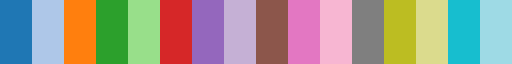

In [13]:
cmap

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   


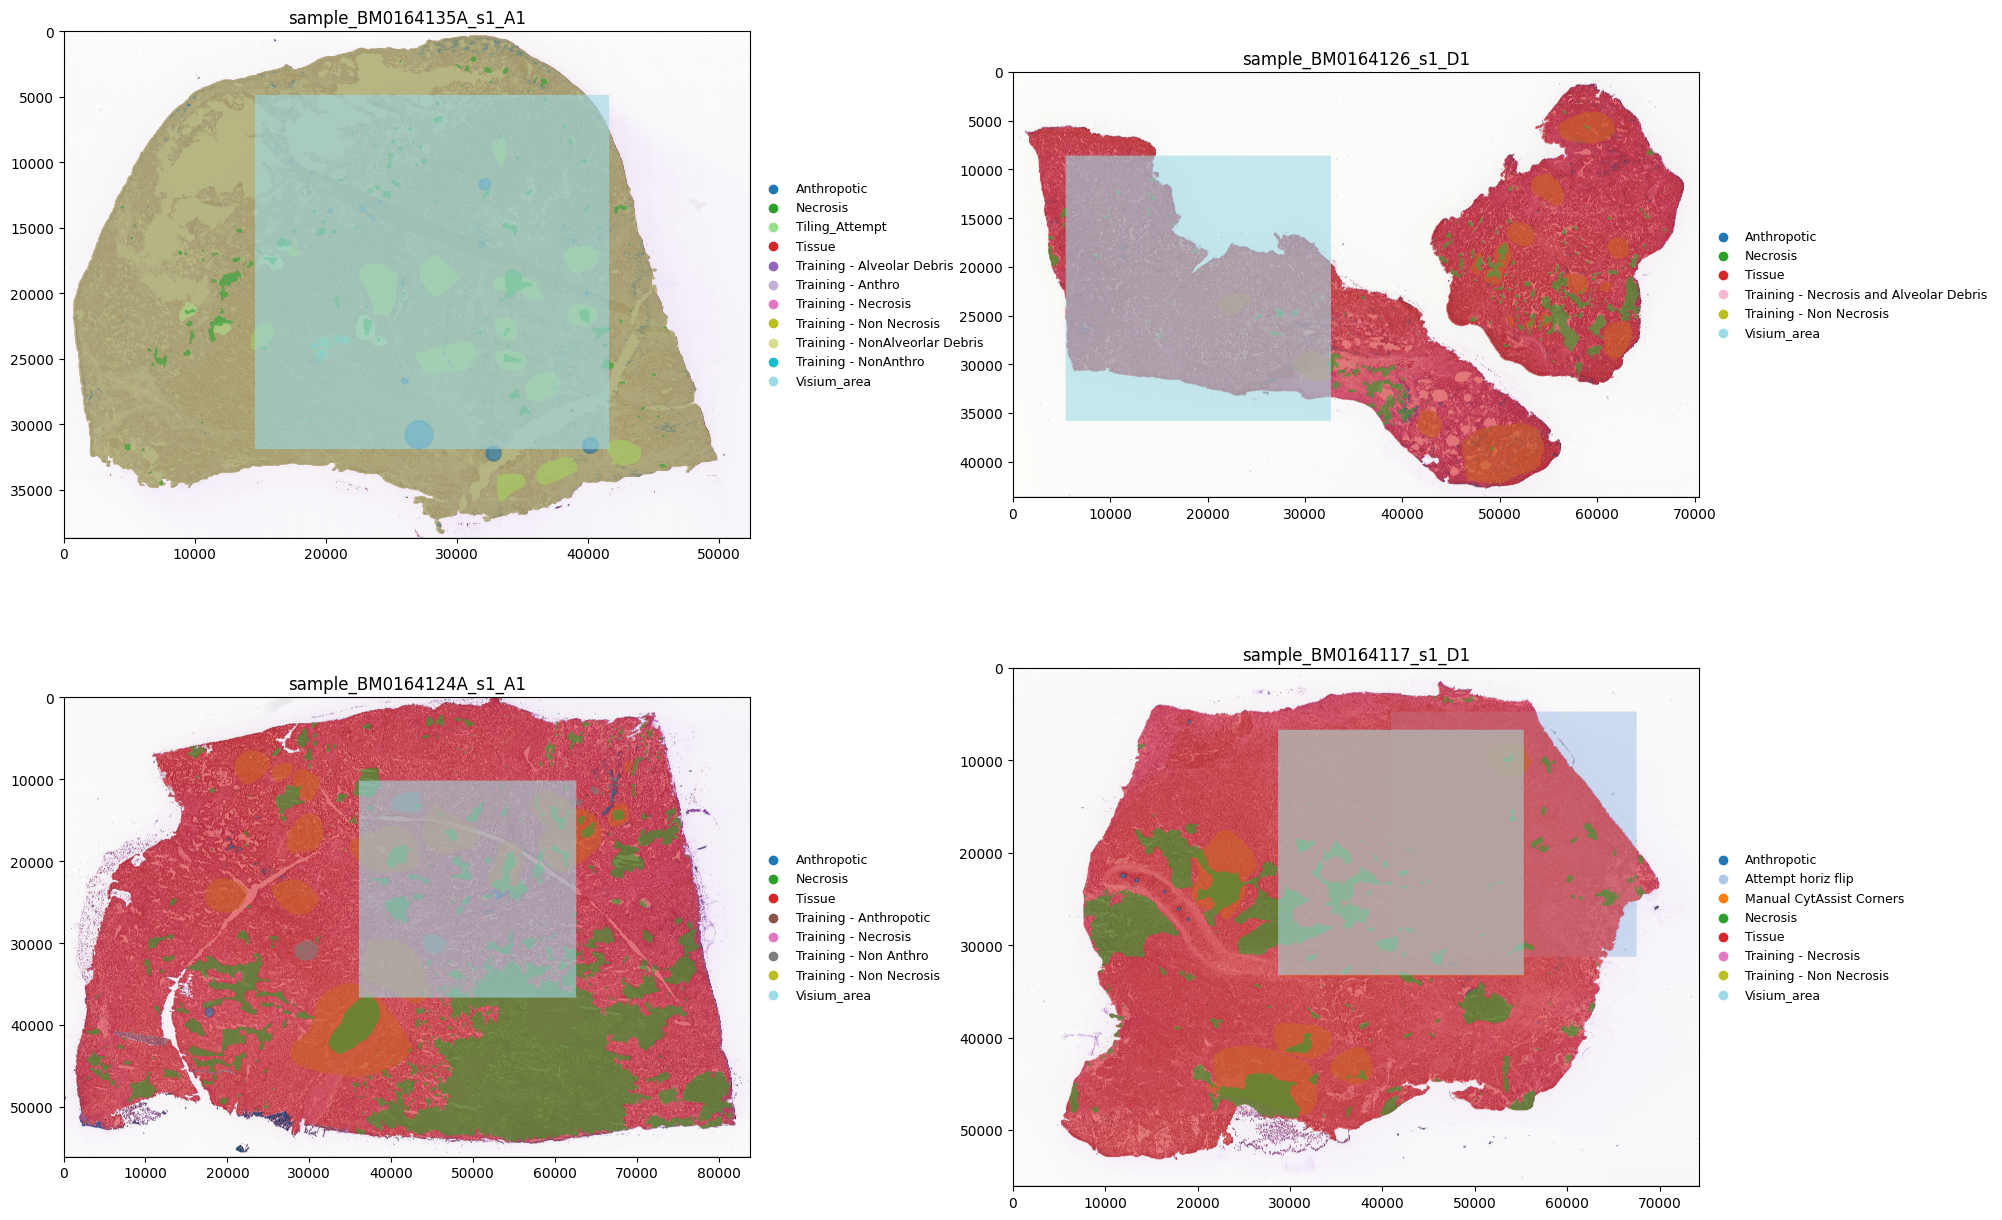

In [10]:
#preview plot for spatialdata object across all annotation classes
axes = plt.subplots(2, 2, figsize=(20, 13), dpi= 300)[1].flatten()
#preview shapes imported 
cmap = matplotlib.cm.get_cmap("tab20", len(all_cats))  # pick e.g. 'tab20', 'tab20b', 'tab20c', 'hsv'
palette_list = [matplotlib.colors.to_hex(cmap(i)) for i in range(len(all_cats))]
#palette_list = pd.Series(palette_list, index=cats)
#['sample_BM0164135A_s1_A1', 'sample_BM0164126_s1_D1', 'sample_BM0164124A_s1_A1', 'sample_BM0164117_s1_D1']
#sample_BM0164135A_s1_A1
sdata = sdata_ls['sample_BM0164135A_s1_A1']
ax = (
    sdata.pl
        .render_images("BM0164135A_s1_A1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=all_cats,          # legend/category order
            palette=palette_list,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[0],
    title="sample_BM0164135A_s1_A1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
#sample_BM0164126_s1_D1
sdata = sdata_ls['sample_BM0164126_s1_D1']
ax = (
    sdata.pl
        .render_images("BM0164126_s1_D1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=all_cats,          # legend/category order
            palette=palette_list,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[1],
    title="sample_BM0164126_s1_D1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
#sample_BM0164124A_s1_A1
sdata = sdata_ls['sample_BM0164124A_s1_A1']
ax = (
    sdata.pl
        .render_images("BM0164124A_s1_A1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=all_cats,          # legend/category order
            palette=palette_list,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[2],
    title="sample_BM0164124A_s1_A1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
#sample_BM0164117_s1_D1
sdata = sdata_ls['sample_BM0164117_s1_D1']
ax = (
    sdata.pl
        .render_images("BM0164117_s1_D1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=all_cats,          # legend/category order
            palette=palette_list,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[3],
    title="sample_BM0164117_s1_D1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
plt.tight_layout()
del sdata

In [ ]:
#preview plot for spatialdata object across only annotation classes of interest
axes = plt.subplots(2, 2, figsize=(20, 13), dpi= 300)[1].flatten()
#preview shapes imported 
#cmap = matplotlib.cm.get_cmap("tab20", len(all_cats))  # pick e.g. 'tab20', 'tab20b', 'tab20c', 'hsv'
#palette_list = [matplotlib.colors.to_hex(cmap(i)) for i in range(len(all_cats))]
indices = [0, 3, 5]#get only relevant colors
palette_list1 = [palette_list[i] for i in indices]
#['sample_BM0164135A_s1_A1', 'sample_BM0164126_s1_D1', 'sample_BM0164124A_s1_A1', 'sample_BM0164117_s1_D1']
annotation_names = ["Anthropotic", "Necrosis", "Tissue"] #annotation of interest
#sample_BM0164135A_s1_A1
sdata = sdata_ls['sample_BM0164135A_s1_A1']
ax = (
    sdata.pl
        .render_images("BM0164135A_s1_A1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=annotation_names,          # legend/category order
            palette=palette_list1,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[0],
    title="sample_BM0164135A_s1_A1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
#sample_BM0164126_s1_D1
sdata = sdata_ls['sample_BM0164126_s1_D1']
ax = (
    sdata.pl
        .render_images("BM0164126_s1_D1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=annotation_names,          # legend/category order
            palette=palette_list1,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[1],
    title="sample_BM0164126_s1_D1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
#sample_BM0164124A_s1_A1
sdata = sdata_ls['sample_BM0164124A_s1_A1']
ax = (
    sdata.pl
        .render_images("BM0164124A_s1_A1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=annotation_names,          # legend/category order
            palette=palette_list1,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[2],
    title="sample_BM0164124A_s1_A1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
#sample_BM0164117_s1_D1
sdata = sdata_ls['sample_BM0164117_s1_D1']
ax = (
    sdata.pl
        .render_images("BM0164117_s1_D1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=annotation_names,          # legend/category order
            palette=palette_list1,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[3],
    title="sample_BM0164117_s1_D1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
plt.tight_layout()
del sdata

In [ ]:
#preview plot for spatialdata object across only annotation classes of interest
axes = plt.subplots(2, 2, figsize=(20, 13), dpi= 300)[1].flatten()
#preview shapes imported 
#cmap = matplotlib.cm.get_cmap("tab20", len(all_cats))  # pick e.g. 'tab20', 'tab20b', 'tab20c', 'hsv'
#palette_list = [matplotlib.colors.to_hex(cmap(i)) for i in range(len(all_cats))]
indices = [0, 3, 5, 15]#get only relevant colors
palette_list2 = [palette_list[i] for i in indices]
#['sample_BM0164135A_s1_A1', 'sample_BM0164126_s1_D1', 'sample_BM0164124A_s1_A1', 'sample_BM0164117_s1_D1']
annotation_names = ["Anthropotic", "Necrosis", "Tissue", "Visium_area"] #annotation of interest
#sample_BM0164135A_s1_A1
sdata = sdata_ls['sample_BM0164135A_s1_A1']
ax = (
    sdata.pl
        .render_images("BM0164135A_s1_A1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=annotation_names,          # legend/category order
            palette=palette_list2,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[0],
    title="sample_BM0164135A_s1_A1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
#sample_BM0164126_s1_D1
sdata = sdata_ls['sample_BM0164126_s1_D1']
ax = (
    sdata.pl
        .render_images("BM0164126_s1_D1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=annotation_names,          # legend/category order
            palette=palette_list2,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[1],
    title="sample_BM0164126_s1_D1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
#sample_BM0164124A_s1_A1
sdata = sdata_ls['sample_BM0164124A_s1_A1']
ax = (
    sdata.pl
        .render_images("BM0164124A_s1_A1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=annotation_names,          # legend/category order
            palette=palette_list2,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[2],
    title="sample_BM0164124A_s1_A1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
#sample_BM0164117_s1_D1
sdata = sdata_ls['sample_BM0164117_s1_D1']
ax = (
    sdata.pl
        .render_images("BM0164117_s1_D1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=annotation_names,          # legend/category order
            palette=palette_list2,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[3],
    title="sample_BM0164117_s1_D1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
plt.tight_layout()
del sdata

In [14]:
annotation_names = ["Tissue", "Anthropotic", "Necrosis"]

for key, s in sdata_ls.items():
    s = assign_annotations_fast(
        s,
        annotation_names=annotation_names,
        annot_shapes_key="annotations_raw",   # change if your shapes key is different
        table_key="square_002um",
        visium_name="Visium_area",            # or leave as default
        target_coordinate_system="global",
        store_as="bool"                       # or "category" to match your earlier columns
    )
    sdata_ls[key] = s 

{'is_Tissue': 10965845, 'is_Anthropotic': 127725, 'is_Necrosis': 220991}
{'is_Tissue': 7422314, 'is_Anthropotic': 52550, 'is_Necrosis': 51699}
{'is_Tissue': 11209218, 'is_Anthropotic': 52179, 'is_Necrosis': 1598940}
{'is_Tissue': 11216178, 'is_Anthropotic': 23671, 'is_Necrosis': 826282}


In [58]:
#update the .zarr file on disk for all the slots that were changed 
for key, s in sdata_ls.items():
    report_info = "Now we are working on spatialdata: " + key
    print(report_info)
    persist_changes(
        s,
        update_elements=["square_002um"],
        new_elements=["annotations_raw", "annotations_clean"],
        update_transformations=True,
        consolidate_metadata=True,
    )

Now we are working on spatialdata: sample_BM0164135A_s1_A1
Now updating square_002um on disk.
Now creating new data record for annotations_raw on disk.
Now creating new data record for annotations_clean on disk.
Now we are working on spatialdata: sample_BM0164126_s1_D1
Now updating square_002um on disk.
Now creating new data record for annotations_raw on disk.
Now creating new data record for annotations_clean on disk.
Now we are working on spatialdata: sample_BM0164124A_s1_A1
Now updating square_002um on disk.
Now creating new data record for annotations_raw on disk.
Now creating new data record for annotations_clean on disk.
Now we are working on spatialdata: sample_BM0164117_s1_D1
Now updating square_002um on disk.
Now creating new data record for annotations_raw on disk.
Now creating new data record for annotations_clean on disk.


In [ ]:
#confirm annotation locations
sc.set_figure_params(dpi = 300, dpi_save = 450, figsize = (5, 5))
sdata_ls['sample_BM0164135A_s1_A1'].tables["square_002um"].obs['is_Tissue'] = \
sdata_ls['sample_BM0164135A_s1_A1'].tables["square_002um"].obs['is_Tissue'].astype('category')

sdata_ls['sample_BM0164135A_s1_A1'].tables["square_002um"].obs['is_Anthropotic'] = \
sdata_ls['sample_BM0164135A_s1_A1'].tables["square_002um"].obs['is_Anthropotic'].astype('category')

sdata_ls['sample_BM0164135A_s1_A1'].tables["square_002um"].obs['is_Necrosis'] = \
sdata_ls['sample_BM0164135A_s1_A1'].tables["square_002um"].obs['is_Necrosis'].astype('category')

sc.pl.embedding(sdata_ls['sample_BM0164135A_s1_A1'].tables["square_002um"]
                , basis="spatial", color = ['is_Tissue', 'is_Anthropotic', 'is_Necrosis']
                , size=0.5, ncols = 3)

In [ ]:
#confirm annotation locations
sdata_ls['sample_BM0164126_s1_D1'].tables["square_002um"].obs['is_Tissue'] = \
sdata_ls['sample_BM0164126_s1_D1'].tables["square_002um"].obs['is_Tissue'].astype('category')

sdata_ls['sample_BM0164126_s1_D1'].tables["square_002um"].obs['is_Anthropotic'] = \
sdata_ls['sample_BM0164126_s1_D1'].tables["square_002um"].obs['is_Anthropotic'].astype('category')

sdata_ls['sample_BM0164126_s1_D1'].tables["square_002um"].obs['is_Necrosis'] = \
sdata_ls['sample_BM0164126_s1_D1'].tables["square_002um"].obs['is_Necrosis'].astype('category')
sc.pl.embedding(sdata_ls['sample_BM0164126_s1_D1'].tables["square_002um"]
                , basis="spatial", color = ['is_Tissue', 'is_Anthropotic', 'is_Necrosis']
                , size=0.5, ncols = 3)

In [ ]:
#confirm annotation locations
sdata_ls['sample_BM0164124A_s1_A1'].tables["square_002um"].obs['is_Tissue'] = \
sdata_ls['sample_BM0164124A_s1_A1'].tables["square_002um"].obs['is_Tissue'].astype('category')

sdata_ls['sample_BM0164124A_s1_A1'].tables["square_002um"].obs['is_Anthropotic'] = \
sdata_ls['sample_BM0164124A_s1_A1'].tables["square_002um"].obs['is_Anthropotic'].astype('category')

sdata_ls['sample_BM0164124A_s1_A1'].tables["square_002um"].obs['is_Necrosis'] = \
sdata_ls['sample_BM0164124A_s1_A1'].tables["square_002um"].obs['is_Necrosis'].astype('category')
sc.pl.embedding(sdata_ls['sample_BM0164124A_s1_A1'].tables["square_002um"]
                , basis="spatial", color = ['is_Tissue', 'is_Anthropotic', 'is_Necrosis']
                , size=0.5, ncols = 3)

In [ ]:
#confirm annotation locations
sdata_ls['sample_BM0164117_s1_D1'].tables["square_002um"].obs['is_Tissue'] = \
sdata_ls['sample_BM0164117_s1_D1'].tables["square_002um"].obs['is_Tissue'].astype('category')

sdata_ls['sample_BM0164117_s1_D1'].tables["square_002um"].obs['is_Anthropotic'] = \
sdata_ls['sample_BM0164117_s1_D1'].tables["square_002um"].obs['is_Anthropotic'].astype('category')

sdata_ls['sample_BM0164117_s1_D1'].tables["square_002um"].obs['is_Necrosis'] = \
sdata_ls['sample_BM0164117_s1_D1'].tables["square_002um"].obs['is_Necrosis'].astype('category')
sc.pl.embedding(sdata_ls['sample_BM0164117_s1_D1'].tables["square_002um"]
                , basis="spatial", color = ['is_Tissue', 'is_Anthropotic', 'is_Necrosis']
                , size=0.5, ncols = 3)

In [ ]:
#update the .zarr file on disk for all the slots that were changed 
for key, s in sdata_ls.items():
    report_info = "Now we are working on spatialdata: " + key
    print(report_info)
    persist_changes(
        s,
        update_elements=["square_002um"],
        #new_elements=["annotations_raw", "annotations_clean"],
        update_transformations=True,
        consolidate_metadata=True,
    )

Now we are working on spatialdata: sample_BM0164135A_s1_A1
Now updating square_002um on disk.
No new element will be recored.
Now we are working on spatialdata: sample_BM0164126_s1_D1
Now updating square_002um on disk.
No new element will be recored.
Now we are working on spatialdata: sample_BM0164124A_s1_A1
Now updating square_002um on disk.
No new element will be recored.
Now we are working on spatialdata: sample_BM0164117_s1_D1
Now updating square_002um on disk.
No new element will be recored.


In [ ]:
#print environment and packages used
%watermark -d -i -m -iv -v --gpu

In [13]:
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
from shapely.ops import unary_union
from shapely.geometry import box
import spatialdata as sd  # make sure you `import spatialdata as sd`

def assign_annotations_fast(
    sdata,
    annotation_names=["Tissue", "Anthropotic", "Necrosis"],
    annot_shapes_key="annotations_raw",
    table_key="square_002um",
    visium_name="Visium_area",                 # if not present, we fall back to the grid bounds
    target_coordinate_system="global",
    store_as="bool",                           # "bool" or "category"
):
    """
    Speedups:
      • crop to Visium area once
      • union polygons per class
      • use clip=False (membership only)
    """
    # --- 0) grab the annotations GeoDataFrame
    ann_gdf = gpd.GeoDataFrame(sdata.shapes[annot_shapes_key]).copy()

    # --- 1) build the Visium region polygon
    vis_rows = ann_gdf.loc[ann_gdf["name"].astype(str) == visium_name, "geometry"]
    if len(vis_rows):
        vis_poly = unary_union(vis_rows.values)
    else:
        # fallback: tight bbox over the squares shapes element
        grid_key = next(k for k in sdata.shapes.keys() if "square_002um" in k)
        grid_gdf = gpd.GeoDataFrame(sdata.shapes[grid_key])
        minx, miny, maxx, maxy = grid_gdf.total_bounds
        vis_poly = box(minx, miny, maxx, maxy)

    # --- 2) crop once to Visium area (fast membership, no clipping)
    sdata_vis = sd.polygon_query(
        sdata, polygon=vis_poly, target_coordinate_system=target_coordinate_system, clip=False
    )

    # We'll write into the original table; indices are the same
    adata = sdata.tables[table_key]

    # initialize destination columns
    if store_as == "bool":
        for a in annotation_names:
            col = f"is_{a}"
            if col not in adata.obs:
                adata.obs[col] = False
    elif store_as == "category":
        for a in annotation_names:
            if a not in adata.obs:
                adata.obs[a] = pd.Categorical.from_codes(
                    np.zeros(adata.n_obs, dtype=np.int8), categories=["unassigned", a]
                )
    else:
        raise ValueError("store_as must be 'bool' or 'category'.")

    # --- 3) union one polygon per annotation and query on the pre-cropped sdata
    for a in annotation_names:
        polys = ann_gdf.loc[ann_gdf["name"].astype(str) == a, "geometry"]
        if polys.empty:
            continue
        poly_union = unary_union(polys.values)

        # restrict the query area to Visium to avoid scanning off-slide
        roi = poly_union.intersection(vis_poly)
        if roi.is_empty:
            continue

        sub = sd.polygon_query(
            sdata_vis, polygon=roi, target_coordinate_system=target_coordinate_system, clip=False
        )
        idx = sub[table_key].obs.index  # rows of *your* main table that fall in this class

        if store_as == "bool":
            adata.obs.loc[idx, f"is_{a}"] = True
        else:
            adata.obs.loc[idx, a] = a

    # quick sanity counts
    if store_as == "bool":
        print({f"is_{a}": int(adata.obs[f"is_{a}"].sum()) for a in annotation_names})
    else:
        from collections import Counter
        print({a: Counter(adata.obs[a]) for a in annotation_names})

    return sdata  # modified in place

In [78]:
from typing import Iterable, Mapping, Optional
import spatialdata as sd
import dask.dataframe as dd
import geopandas
import xarray as xr
import anndata as ad

def persist_changes(
    sdata: sd.SpatialData,
    update_elements=None, #Iterable[str]
    new_elements=None, #Iterable[str]
    update_transformations: bool = True,
    consolidate_metadata: bool = True,
) -> None:
    """
    Write only the selected elements of a SpatialData object back to its
    associated Zarr store. Does NOT touch other elements (e.g., large images).

    Parameters
    ----------
    sdata : SpatialData
        The object you’ve modified in-memory (must already be associated to a Zarr store).
    elements : iterable of str
        Names of elements to persist, e.g. ["square_002um", "annotation_labels_down_3class"].
        Works for tables, labels, shapes, points, images.
    update_transformations : bool
        If True, also update the transformations/metadata on-disk.
        Useful if you added/changed transforms for shapes/labels.
    consolidate_metadata : bool
        If True, re-write consolidated Zarr metadata for faster reads.

    Notes
    -----
    - This uses SpatialData’s incremental I/O: `write_element`, `write_transformations`,
      `write_metadata`, `write_consolidated_metadata`. See the docs.  # noqa
    """
    # Sanity: check this object is already tied to a Zarr store
    try:
        _ = sdata.elements_paths_on_disk()  # raises if no associated store
    except Exception as e:
        raise RuntimeError(
            "This SpatialData object is not associated with a Zarr store. "
            "Write it once with `sdata.write(<existing_store_path>)`, "
            "then call persist_changes()."
        ) from e

    # Write only the requested elements
    if update_elements is None:
        report_type0 = "No element will be updated."
        print(report_type0)
    else:
        for name in update_elements:
            if name not in sdata:
                raise KeyError(f"Element '{name}' not found in SpatialData.")
                #generate datatype to test
                #datatype_1 = isinstance(sdata[name], geopandas.GeoDataFrame)#test if shape is on disk
                #datatype_2 = isinstance(sdata[name], ad.AnnData)#test if table is on disk
                #datatype_3 = isinstance(sdata[name], xr.DataArray)#test if image is on disk
                #datatype_4 = isinstance(sdata[name], dd.DataFrame)#test if points is on disk
            report_type1 = "Now updating " + name + " on disk."
            #if datatype_1 or datatype_2 or datatype_3 or datatype_4: #if the data is already on disk
            element_name = "backup_" + name
            print(report_type1)
            # copy the table to a backup table
            sdata[element_name] = sdata[name]
            sdata.write_element(element_name)# <- incremental write for just this element
            # rewrite the original one
            sdata.delete_element_from_disk(name)
            sdata.write_element(name)
            # remove the backup copy
            sdata.delete_element_from_disk(element_name)
            del sdata.tables[element_name]
    #for new data that is not on disk
    if new_elements is None:
        report_type3 = "No new element will be recored."
        print(report_type3)
    else:
        for name in new_elements:
            if name not in sdata:
                raise KeyError(f"Element '{name}' not found in SpatialData.")
            report_type2 = "Now creating new data record for " + name + " on disk."
            print(report_type2)
            sdata.write_element(name)
            
    # Optional: update transforms/metadata (lightweight)
    if update_transformations:
        sdata.write_transformations()
        sdata.write_metadata()
        if consolidate_metadata:
            sdata.write_consolidated_metadata()

In [ ]:
#preview plot for spatialdata object across only annotation classes of interest
axes = plt.subplots(2, 2, figsize=(20, 13), dpi= 300)[1].flatten()
#preview shapes imported 
#cmap = matplotlib.cm.get_cmap("tab20", len(all_cats))  # pick e.g. 'tab20', 'tab20b', 'tab20c', 'hsv'
#palette_list = [matplotlib.colors.to_hex(cmap(i)) for i in range(len(all_cats))]
indices = [0, 3, 5, 15]#get only relevant colors
palette_list2 = [palette_list[i] for i in indices]
#['sample_BM0164135A_s1_A1', 'sample_BM0164126_s1_D1', 'sample_BM0164124A_s1_A1', 'sample_BM0164117_s1_D1']
annotation_names = ["Anthropotic", "Necrosis", "Tissue", "Visium_area"] #annotation of interest
#sample_BM0164135A_s1_A1
sdata = sdata_ls['sample_BM0164135A_s1_A1']
ax = (
    sdata.pl
        .render_images("BM0164135A_s1_A1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=annotation_names,          # legend/category order
            palette=palette_list2,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[0],
    title="sample_BM0164135A_s1_A1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
#sample_BM0164126_s1_D1
sdata = sdata_ls['sample_BM0164126_s1_D1']
ax = (
    sdata.pl
        .render_images("BM0164126_s1_D1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=annotation_names,          # legend/category order
            palette=palette_list2,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[1],
    title="sample_BM0164126_s1_D1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
#sample_BM0164124A_s1_A1
sdata = sdata_ls['sample_BM0164124A_s1_A1']
ax = (
    sdata.pl
        .render_images("BM0164124A_s1_A1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=annotation_names,          # legend/category order
            palette=palette_list2,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[2],
    title="sample_BM0164124A_s1_A1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
#sample_BM0164117_s1_D1
sdata = sdata_ls['sample_BM0164117_s1_D1']
ax = (
    sdata.pl
        .render_images("BM0164117_s1_D1_hires_image")          # your image key
        .pl.render_shapes(
            "annotations_clean",
            color="name",            # now categorical
            groups=annotation_names,          # legend/category order
            palette=palette_list2,       # one color per category (aligned with `groups`)
            method="matplotlib",        # enables legend for categorical colors
            fill_alpha=0.6,
            outline=True,
            outline_width=0.5,
            outline_color="#000000",
        )
)
ax.pl.show(
    ax=axes[3],
    title="sample_BM0164117_s1_D1",
    coordinate_systems="global",
    legend_loc="right margin",          # or 'upper right', 'lower left', etc.
    legend_fontsize=9,
    colorbar=False    
)
plt.tight_layout()
del sdata